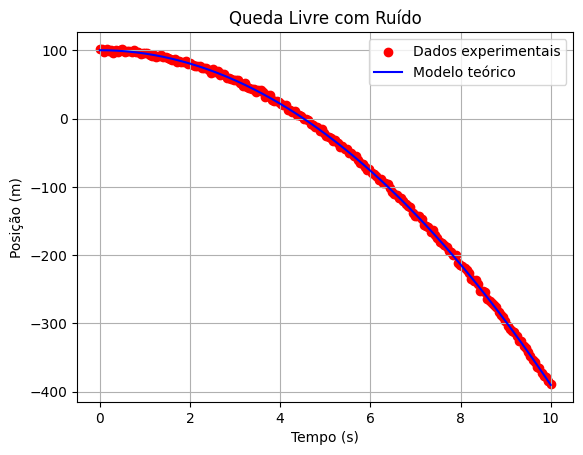

In [1]:
# gerando daddos para o primeiro exemplo: queda livre

import numpy as np
import matplotlib.pyplot as plt

# parametros
y0 = 100
g = 9.8

#criando vetor de tempo
t0, t1 = 0, 10 #segundos
t = np.linspace(t0, t1, (t1-t0)*20)

#criando vetor de posicao
y = y0 - 0.5*g*t**2

'''
sem definir o referencial por enquanto.S
#limitando o chão em y = 0
y[y < 0] = 0
'''
#colocando ruido
erro_relativo = 0.02
ruido = np.random.normal(0, erro_relativo * y0, size=t.shape)
y_experimental = y + ruido

#plotando os dados
plt.scatter(t, y_experimental, label='Dados experimentais', color='red')
plt.plot(t, y, label='Modelo teórico', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (m)')
plt.title('Queda Livre com Ruído')
plt.legend()
plt.grid()

plt.show()

#salvando os dados em um arquivo csv para o PySR 
import pandas as pd
df = pd.DataFrame({'tempo': t, 'posicao': y_experimental})
df.to_csv('../data/raw/dados_queda_livre.csv', index=False)



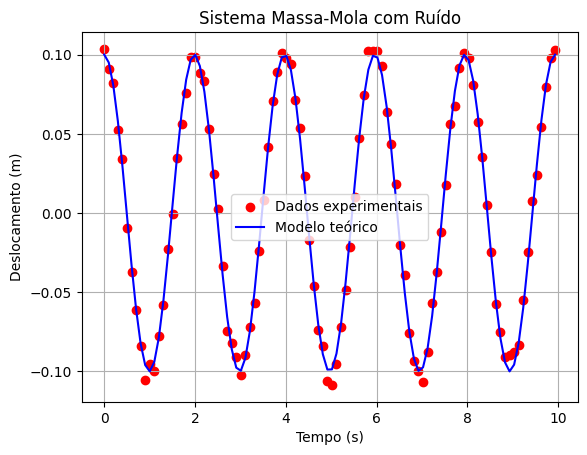

In [34]:
# segundo: sistema massa-mola

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

# parametros
m = 1.0  # massa (kg)
k = 10.0  # constante da mola (N/m)
A = 0.1  # amplitude (m)
omega = np.sqrt(k/m)  # frequência angular (rad/s)
n_ciclos = 5
T = 2 * np.pi / omega  # período (s)
t1 = n_ciclos * T  # tempo total para n ciclos

# criando vetor de tempo
fator_nyquist = 20        # 20 amostras por ciclo
f = omega / (2 * np.pi)   # frequência do sistema
fs = fator_nyquist * f    # frequência de amostragem
n_pontos = int(fs * t1)   # total de pontos
t = np.linspace(t0, t1, n_pontos)

# solução analítica --->> x_analitico = A * np.cos(omega * t)
#solução numérica com scipy.integrate

def sistema_massa_mola(t, y):
    x, v = y
    dxdt = v
    dvdt = - (k/m) * x
    return [dxdt, dvdt]
y0 = [A, 0]  # condição inicial: posição A e velocidade 0
solucao = spi.solve_ivp(sistema_massa_mola, [t0, t1], y0, t_eval=t)
x_numerico = solucao.y[0]



# adicionando ruído
erro_relativo = 0.05
ruido = np.random.normal(0, erro_relativo * A, size=t.shape)
x_experimental = x_numerico + ruido

# plotando os dados
plt.scatter(t, x_experimental, label='Dados experimentais', color='red')
plt.plot(t, x_numerico, label='Modelo teórico', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento (m)')
plt.title('Sistema Massa-Mola com Ruído')
plt.legend()
plt.grid()
plt.show()

#salvando os dados em um arquivo csv para o PySR
import pandas as pd 
df = pd.DataFrame({'tempo': t, 'deslocamento': x_experimental})
df.to_csv('../data/raw/dados_massa_mola.csv', index=False)




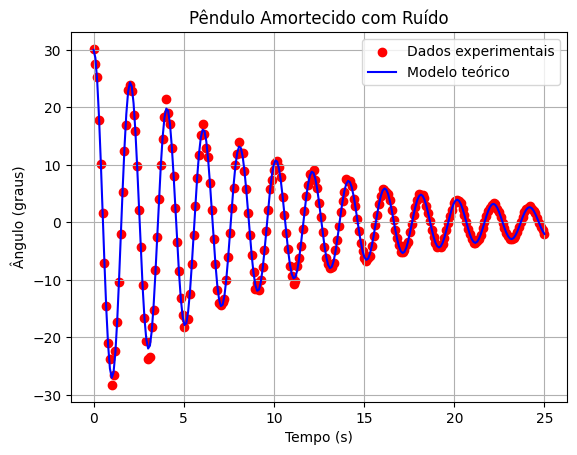

In [35]:
# 3 - pendulo amortecido
# equação do movimento: d2theta/dt2 + (b/m)*dtheta/dt + (g/L)*sin(theta) = 0

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

# parametros
m = 1.0  # massa (kg)
L = 1.0  # comprimento do pendulo (m)
b = 0.2  # coeficiente de amortecimento (kg/s)
g = 9.8  # aceleração da gravidade (m/s^2)
theta0 = np.radians(30)  # ângulo inicial (30 graus)
tau = m / b  # tempo característico de amortecimento


# criando vetor de tempo
t0, t1 = 0, 5 * tau  # segundos
fator_nyquist = 20        # 20 amostras por ciclo
f = np.sqrt(g/L) / (2 * np.pi)   # frequência do sistema
fs = fator_nyquist * f    # frequência de amostragem
n_pontos = int(fs * (t1 - t0))   # total de pontos
t = np.linspace(t0, t1, n_pontos)

# solução numérica com scipy.integrate
def sistema_pendulo_amortecido(t, y):
    theta, omega = y
    dthetadt = omega
    domegadt = - (b/m) * omega - (g/L) * np.sin(theta)
    return [dthetadt, domegadt]
y0 = [theta0, 0]  # condição inicial: ângulo inicial e velocidade angular zero

solucao = spi.solve_ivp(sistema_pendulo_amortecido, [t0, t1], y0, t_eval=t)
theta_numerico = solucao.y[0]

# adicionando ruído
erro_relativo = 0.05
ruido = np.random.normal(0, erro_relativo * np.abs(theta_numerico), size=t.shape)
theta_experimental = theta_numerico + ruido


# plotando os dados
plt.scatter(t, np.degrees(theta_experimental), label='Dados experimentais', color='red')
plt.plot(t, np.degrees(theta_numerico), label='Modelo teórico', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('Ângulo (graus)')
plt.title('Pêndulo Amortecido com Ruído')
plt.legend()
plt.grid()
plt.show()

#salvando os dados em um arquivo csv para o PySR  
import pandas as pd
df = pd.DataFrame({'tempo': t, 'angulo': np.degrees(theta_experimental)})
df.to_csv('../data/raw/dados_pendulo_amortecido.csv', index=False)


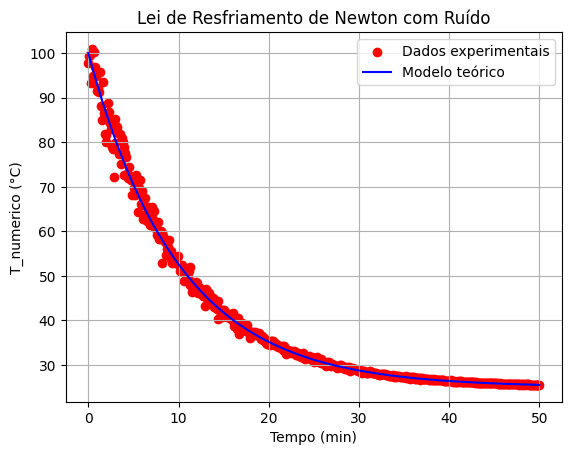

In [36]:
# lei de resfriamento de newton
#equação: dT/dt = -k*(T - T_ambiente)

import numpy as np
import matplotlib.pyplot as plt

#parametros
T0 = 100  # temperatura inicial (°C)
T_ambiente = 25  # temperatura ambiente (°C)
k = 0.1  # constante de resfriamento (1/min)

#criando vetor de tempo em função de tau até 5tau
tau = 1/k  # tempo característico de resfriamento
t0, t1 = 0, 5 * tau  # minutos
t = np.linspace(t0, t1, 500)

#solução numerica
def resfriamento(t, T):
    dTdt = -k * (T - T_ambiente)
    return dTdt
from scipy.integrate import solve_ivp
solucao = solve_ivp(resfriamento, [t0, t1], [T0], t_eval=t)
T_numerico = solucao.y[0]

#adicionando ruído
erro_relativo = 0.05
ruido = np.random.normal(0, erro_relativo * np.abs(T_numerico - T_ambiente), size=t.shape)
T_experimental = T_numerico + ruido

#plotando os dados
plt.scatter(t, T_experimental, label='Dados experimentais', color='red')
plt.plot(t, T_numerico, label='Modelo teórico', color='blue')
plt.xlabel('Tempo (min)')
plt.ylabel('T_numerico (°C)')
plt.title('Lei de Resfriamento de Newton com Ruído')
plt.legend()
plt.grid()
plt.show()

#salvando os dados em um arquivo csv para o PySR 
import pandas as pd
df = pd.DataFrame({'tempo': t, 'temperatura': T_experimental})
df.to_csv('../data/raw/dados_resfriamento_newton.csv', index=False)



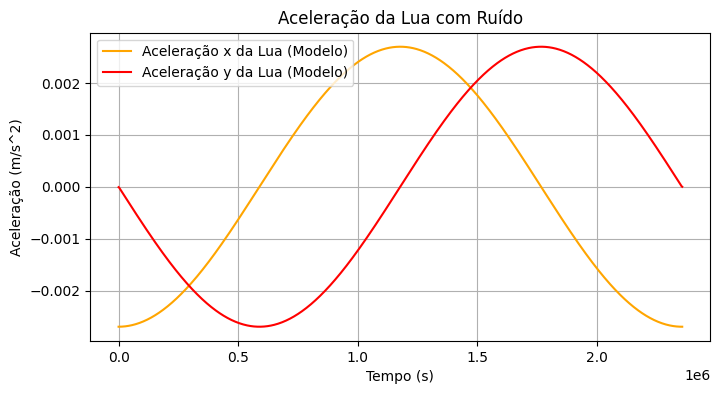

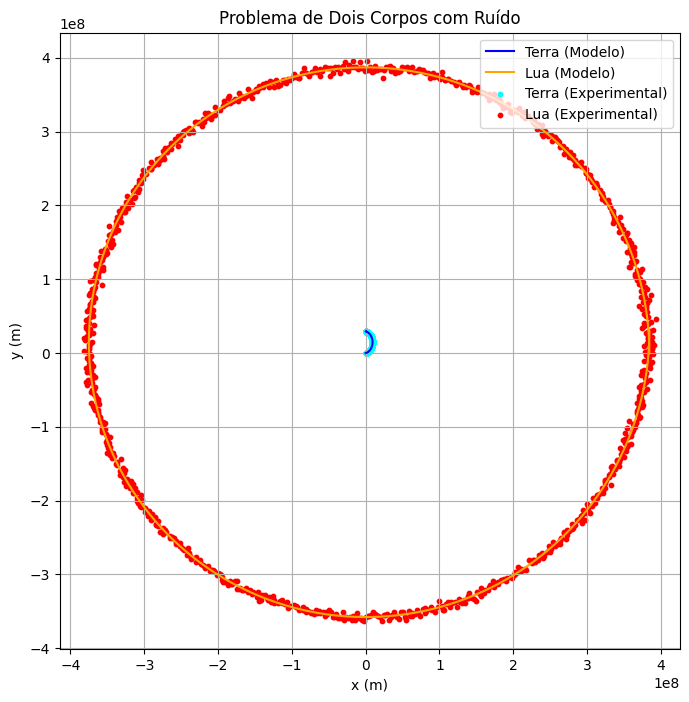

In [32]:
# 5 - tentativa: problema de dois corpos

'''
x1'' = G * m2 * (x2 - x1) / r^3
y1'' = G * m2 * (y2 - y1) / r^3
simetrica para a massa 2
r = sqrt((x2 - x1)^2 + (y2 - y1)^2)
'''

import numpy as np
import matplotlib.pyplot as plt


#parametros
m1 = 5.972e24  # massa da Terra (kg)
m2 = 7.348e22  # massa da Lua (kg)
r1 = np.array([0, 0])  # posição inicial da Terra (m)
r2 = np.array([384400000, 0])  # posição inicial da Lua (m)
mi = m1 * m2 / (m1 + m2)  # massa reduzida
M = m1 + m2  # massa total
G = 6.67430e-11  # constante gravitacional (m^3 kg^-1 s^-2)
r = r1 - r2  # vetor de posição relativa


def sistema_dois_corpos(t, y):
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
    r_vec = np.array([x2 - x1, y2 - y1])
    r_mag = np.linalg.norm(r_vec)
    r_hat = r_vec / r_mag
    a1 = G * m2 / r_mag**2 * r_hat
    a2 = -G * m1 / r_mag**2 * r_hat
    return [vx1, vy1, vx2, vy2, a1[0], a1[1], a2[0], a2[1]]
from scipy.integrate import solve_ivp


r_mag_inicial = np.linalg.norm(r2 - r1)
v_circular = np.sqrt(G * M / r_mag_inicial)
y0 = np.array([r1[0], r1[1], r2[0], r2[1], 0.0, 0.0, 0.0, v_circular], dtype=float)
solucao = solve_ivp(sistema_dois_corpos, [t0, t1], y0, t_eval=t, rtol=1e-10, atol=1e-10) #solver com maior precisão e tentando nao perder energia
x1, y1, x2, y2 = solucao.y[0], solucao.y[1], solucao.y[2], solucao.y[3]

# adicionando ruído
erro_relativo = 0.01

ruido_x2 = np.random.normal(0, erro_relativo * np.abs(x2), size=t.shape)
ruido_y2 = np.random.normal(0, erro_relativo * np.abs(y2), size=t.shape)
r_mag = np.sqrt((x2-x1)**2 + (y2-y1)**2)

ruido_x1 = np.random.normal(0, erro_relativo * r_mag, size=t.shape)

x2_experimental = x2 + ruido_x2
y2_experimental = y2 + ruido_y2

#aceleração da lua com numpy.gradient
vx2 = solucao.y[6]
vy2 = solucao.y[7]

ax2 = np.gradient(vx2, t)
ay2 = np.gradient(vy2, t)

#plotando ax2 contra tempo pra ver se ta certo o calculod e aceleração
plt.figure(figsize=(8, 4))
plt.plot(t, ax2, label='Aceleração x da Lua (Modelo)', color='orange')
plt.plot(t, ay2, label='Aceleração y da Lua (Modelo)', color='red')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s^2)')
plt.title('Aceleração da Lua com Ruído')
plt.legend()
plt.grid()
plt.show()


# plotando os dados
plt.figure(figsize=(8, 8))
plt.plot(x1, y1, label='Terra (Modelo)', color='blue')
plt.plot(x2, y2, label='Lua (Modelo)', color='orange')
plt.scatter(x1, y1, label='Terra (Experimental)', color='cyan', s=10)
plt.scatter(x2_experimental, y2_experimental, label='Lua (Experimental)', color='red', s=10)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Problema de Dois Corpos com Ruído')
plt.legend()
plt.grid()
plt.axis('equal')
plt.show()


#salvando os dados em um arquivo csv para o PySR 
# colunas x2, y2, r_mag, ax2, ay2
import pandas as pd
dados = pd.DataFrame({
    'x2': x2_experimental,
    'y2': y2_experimental,
    'r_mag': r_mag,
    'ax2': ax2,
    'ay2': ay2
})
dados.to_csv('../data/raw/dados_dois_corpos.csv', index=False)




In [38]:
# particula na caixa (sistema quantico mais simples possivel)
#partícula confinada entre duas paredes em x=0 e x=L com potencial zero dentro e infinito fora
#-ℏ²/2m · d²ψ/dx² = E·ψ

'''
condições: o objetivo é gerar dados de n, L, m -> En. e descobrir a relação En = n²π²ℏ²/2mL² 
testando diferentes condições e verificar a energia
pensar nas unidades atomicas para evitar os numeros muito pequenos

'''

import numpy as np
import matplotlib.pyplot as plt

#parametros emunidade atomicas
hbar = 1.0  # constante de Planck reduzida (u.a.)

#vetores para as combinações de n, L, m
n_values = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # números quânticos
L_values = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0])  # comprimentos da caixa (u.a.)
m_values = np.array([0.5, 1.0, 1.5, 2.0])  # massas da partícula (u.a.)
#intertools.product para gerar todas as combinações
import itertools
combinacoes = list(itertools.product(n_values, L_values, m_values))
dados = []
for n, L, m in combinacoes:
    E = (n**2 * np.pi**2 * hbar**2) / (2 * m * L**2)
    dados.append((n, L, m, E))

#introduzindo ruido baseado no alargamento instrumental, ignorando em medições de espectroscopia e usando o principio da incerteza deltaE*deltaT >= hbar/2 para facilitar
erro_relativo = 0.02

E_real = np.array([E for _, _, _, E in dados])
sigma = erro_relativo * E_real
ruido = np.random.normal(0, sigma)
E_medida = E_real + ruido

#salvando os dados em um arquivo csv para o PySR
import pandas as pd
df = pd.DataFrame(dados, columns=['n', 'L', 'm', 'E_medida'])
df.to_csv('../data/raw/dados_particula_caixa.csv', index=False) 

